# Product & Customer Analysis — Olist E-Commerce

Analyzing product category performance and customer purchasing behavior using the cleaned 
`analysis_df` built in `01_data_cleaning.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

analysis_df = pd.read_csv('../data/analysis_df.csv')

date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date', 'shipping_limit_date']
for col in date_cols:
    analysis_df[col] = pd.to_datetime(analysis_df[col])

print(analysis_df.shape)

(112650, 34)


## 2. Top Product Categories by Revenue

**Question:** Which product categories generate the most revenue?

**Note:** 17 rows have no category (traced in `01_data_cleaning.ipynb` to a single dropped product 
with no usable data) — excluded automatically from this groupby.

In [2]:
category_revenue = analysis_df.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

category_revenue.head(15)

,product_category_name_english,total_revenue,order_count
43,health_beauty,1258681.34,8836
73,watches_gifts,1205005.68,5624
7,bed_bath_table,1036988.68,9417
67,sports_leisure,988048.97,7720
15,computers_accessories,911954.32,6689
39,furniture_decor,729762.49,6449
20,cool_stuff,635290.85,3632
49,housewares,632248.66,5884
5,auto,592720.11,3897
42,garden_tools,485256.46,3518


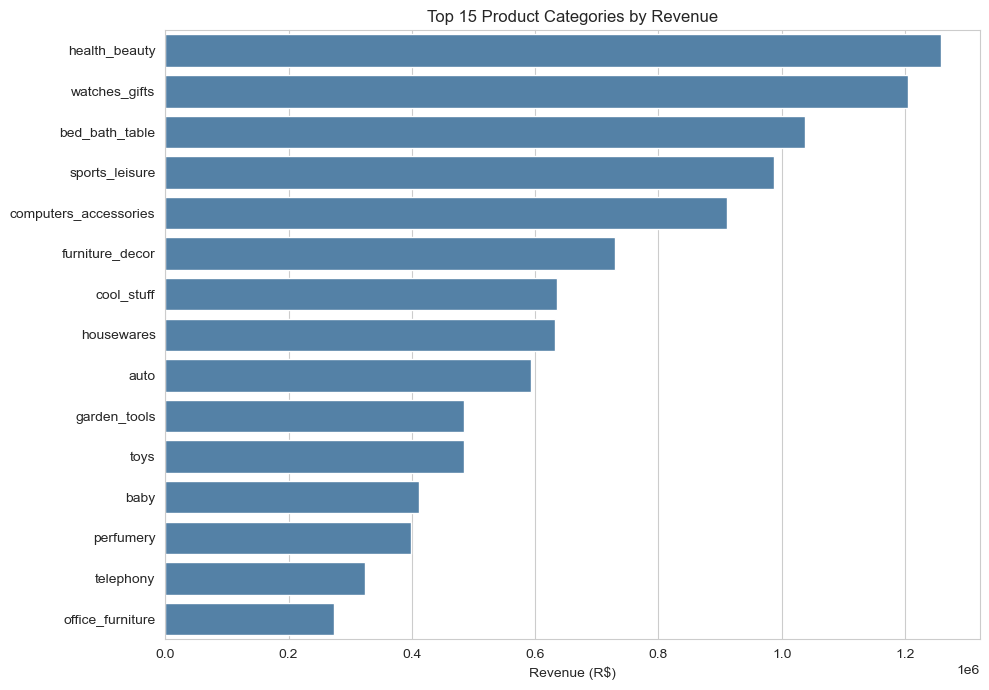

In [3]:
top15 = category_revenue.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top15, x='total_revenue', y='product_category_name_english', color='steelblue')
plt.title('Top 15 Product Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../images/top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Revenue is moderately concentrated — the top 10 of 74 categories account for ~62% 
of total revenue. `health_beauty` leads (R$1.26M), closely followed by `watches_gifts` (R$1.21M) 
and `bed_bath_table` (R$1.04M).

## 3. Volume vs. Premium Categories

**Question:** Which categories sell in high volume, and which command premium prices — are they the same categories?

**Note:** Categories with fewer than 30 items sold are excluded from the "premium" ranking, since 
a tiny sample size can produce a misleadingly high average price from just 1-2 expensive sales.

In [6]:
category_stats = analysis_df.groupby('product_category_name_english').agg(
    item_count=('order_item_id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

category_stats_filtered = category_stats[category_stats['item_count'] >= 30]

top_volume = category_stats_filtered.sort_values('item_count', ascending=False).head(10)
top_premium = category_stats_filtered.sort_values('avg_price', ascending=False).head(10)

print(top_volume)
print()
print(top_premium)

   product_category_name_english  item_count   avg_price
7                 bed_bath_table       11115   93.296327
43                 health_beauty        9670  130.163531
67                sports_leisure        8641  114.344285
39               furniture_decor        8334   87.564494
15         computers_accessories        7827  116.513903
49                    housewares        6964   90.788148
73                 watches_gifts        5991  201.135984
70                     telephony        4545   71.213978
42                  garden_tools        4347  111.630196
5                           auto        4235  139.957523

            product_category_name_english  item_count    avg_price
14                              computers         203  1098.340542
66  small_appliances_home_oven_and_coffee          76   624.285658
45                      home_appliances_2         238   476.124958
0              agro_industry_and_commerce         212   342.124858
57                    musical_instrum

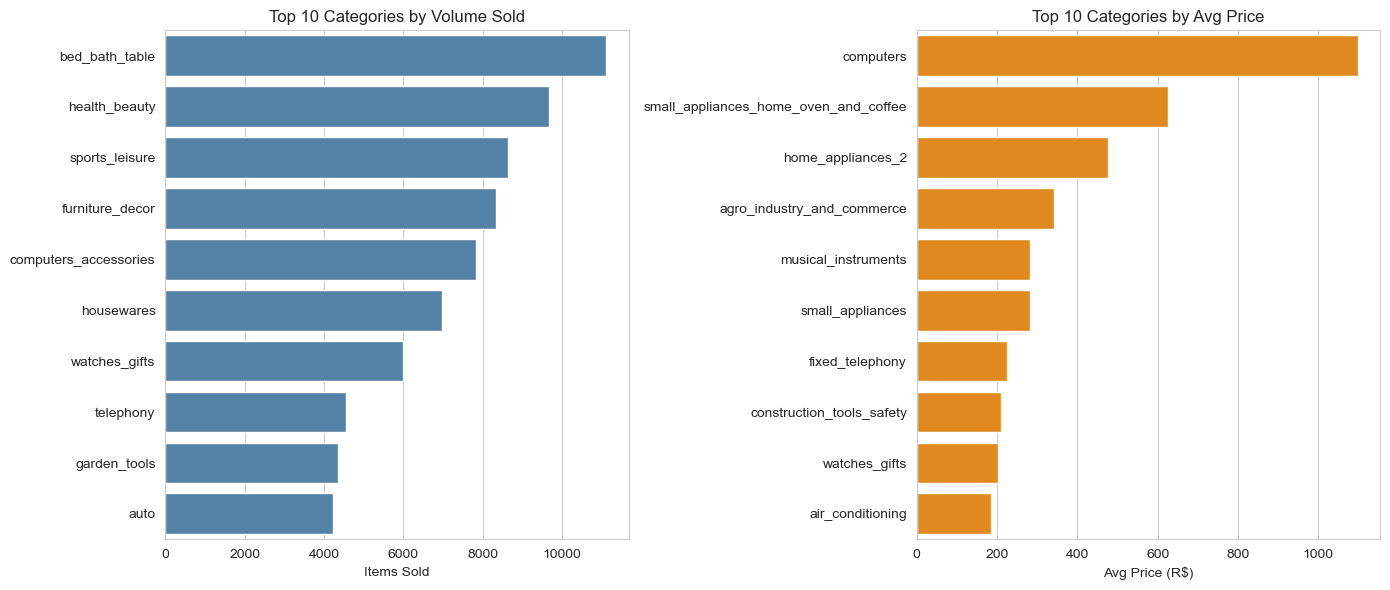

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_volume, x='item_count', y='product_category_name_english', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Categories by Volume Sold')
axes[0].set_xlabel('Items Sold')
axes[0].set_ylabel('')

sns.barplot(data=top_premium, x='avg_price', y='product_category_name_english', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Categories by Avg Price')
axes[1].set_xlabel('Avg Price (R$)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../images/volume_vs_premium_categories.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**  High-volume categories (bed_bath_table, health_beauty, sports_leisure) sell in the 
R 87-130 average price range — everyday purchases. Premium categories (computers at R 1,098 avg, 
small appliances at R 624 avg) sell in much smaller volumes, as expected for occasional big-ticket 
purchases. `watches_gifts` stands out as the only category combining strong volume (5,991 items) 
with premium pricing (R$201 avg) — a particularly high-value category for the business.

## 4. Review Score by Category

**Question:** Does customer satisfaction (review score) vary meaningfully by product category?

**Note:** Categories with fewer than 30 items are excluded to avoid small-sample noise. 
Overall average review score across all orders is 4.03.

In [8]:
category_reviews = analysis_df.groupby('product_category_name_english').agg(
    avg_review_score=('review_score', 'mean'),
    review_count=('review_score', 'count'),
    item_count=('order_item_id', 'count')
).reset_index()

category_reviews_filtered = category_reviews[category_reviews['item_count'] >= 30]

lowest = category_reviews_filtered.sort_values('avg_review_score').head(10)
highest = category_reviews_filtered.sort_values('avg_review_score', ascending=False).head(10)

print(lowest)
print()
print(highest)

        product_category_name_english  avg_review_score  review_count  \
23                diapers_and_hygiene          3.256410            39   
58                   office_furniture          3.488372          1677   
46                     home_comfort_2          3.629630            27   
30              fashion_male_clothing          3.641221           131   
34                    fixed_telephony          3.681992           261   
27             fashio_female_clothing          3.750000            48   
59                     party_supplies          3.767442            43   
41  furniture_mattress_and_upholstery          3.815789            38   
47                       home_confort          3.831019           432   
72                            unknown          3.831425          1572   

    item_count  
23          39  
58        1691  
46          30  
30         132  
34         264  
27          48  
59          43  
41          38  
47         434  
72        1586  

        

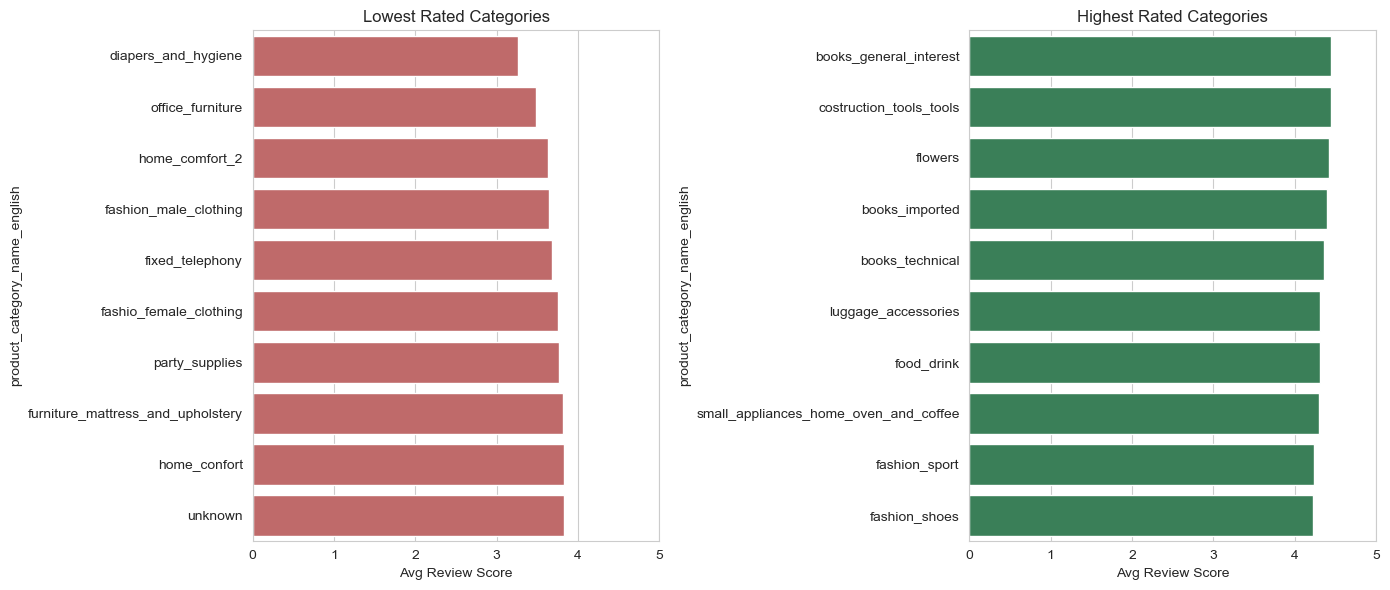

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=lowest, x='avg_review_score', y='product_category_name_english', ax=axes[0], color='indianred')
axes[0].set_title('Lowest Rated Categories')
axes[0].set_xlabel('Avg Review Score')
axes[0].set_xlim(0, 5)

sns.barplot(data=highest, x='avg_review_score', y='product_category_name_english', ax=axes[1], color='seagreen')
axes[1].set_title('Highest Rated Categories')
axes[1].set_xlabel('Avg Review Score')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.savefig('../images/review_score_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Overall satisfaction is solid (4.03 avg), but furniture-related categories 
(`office_furniture` at 3.49 with 1,677 reviews, `home_comfort_2`, `home_confort`) rate notably 
below average — likely linked to delivery complications common with bulky items, worth 
cross-checking in the delivery analysis. Simple, low-risk categories like books and flowers 
rate highest (4.3-4.45).

## 5. Repeat Customers

**Question:** What % of customers are repeat buyers, and how much more do they spend?

Using `customer_unique_id` (the real person) rather than `customer_id` (generated per order), 
as established in `01_data_cleaning.ipynb`.

In [10]:
customer_orders = analysis_df.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    total_spend=('price', 'sum')
).reset_index()

customer_orders['customer_type'] = customer_orders['order_count'].apply(
    lambda x: 'repeat' if x > 1 else 'one-time'
)

summary = customer_orders.groupby('customer_type').agg(
    num_customers=('customer_unique_id', 'count'),
    avg_spend=('total_spend', 'mean'),
    total_spend=('total_spend', 'sum')
).reset_index()

summary

,customer_type,num_customers,avg_spend,total_spend
0,one-time,92507,138.674390,12828351.84
1,repeat,2913,262.029475,763291.86


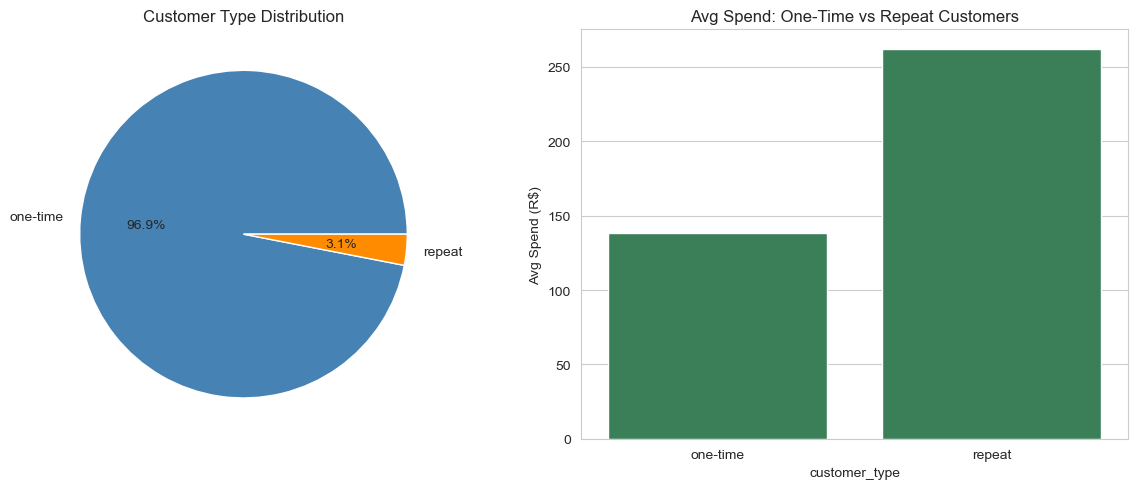

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(summary['num_customers'], labels=summary['customer_type'], autopct='%1.1f%%',
            colors=['steelblue', 'darkorange'])
axes[0].set_title('Customer Type Distribution')

sns.barplot(data=summary, x='customer_type', y='avg_spend', ax=axes[1], color='seagreen')
axes[1].set_title('Avg Spend: One-Time vs Repeat Customers')
axes[1].set_ylabel('Avg Spend (R$)')

plt.tight_layout()
plt.savefig('../images/repeat_customers.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Only 3.05% of customers made repeat purchases, but they spent nearly 2x more on 
average (R 262.03 vs R$138.67). Despite this, repeat customers still account for only ~5.6% of 
total revenue due to their small numbers. Note: the dataset spans ~2 years, a relatively short 
window to observe repeat behavior — this may understate true repeat rates for infrequently 
purchased categories like furniture or electronics.

## 6. Customer Distribution by State & City

**Question:** Where are customers concentrated geographically?

In [12]:
unique_customers = analysis_df.drop_duplicates(subset='customer_unique_id')

state_dist = unique_customers.groupby('customer_state').agg(
    num_customers=('customer_unique_id', 'nunique')
).reset_index().sort_values('num_customers', ascending=False)

city_dist = unique_customers.groupby('customer_city').agg(
    num_customers=('customer_unique_id', 'nunique')
).reset_index().sort_values('num_customers', ascending=False)

print(state_dist.head(10))
print()
print(city_dist.head(10))

   customer_state  num_customers
25             SP          39972
18             RJ          12300
10             MG          11175
22             RS           5247
17             PR           4838
23             SC           3509
4              BA           3256
6              DF           2061
7              ES           1955
8              GO           1939

              customer_city  num_customers
3587              sao paulo          14847
3146         rio de janeiro           6571
452          belo horizonte           2652
557                brasilia           2054
1141               curitiba           1452
705                campinas           1384
2955           porto alegre           1320
3238               salvador           1201
1526              guarulhos           1143
3419  sao bernardo do campo            898


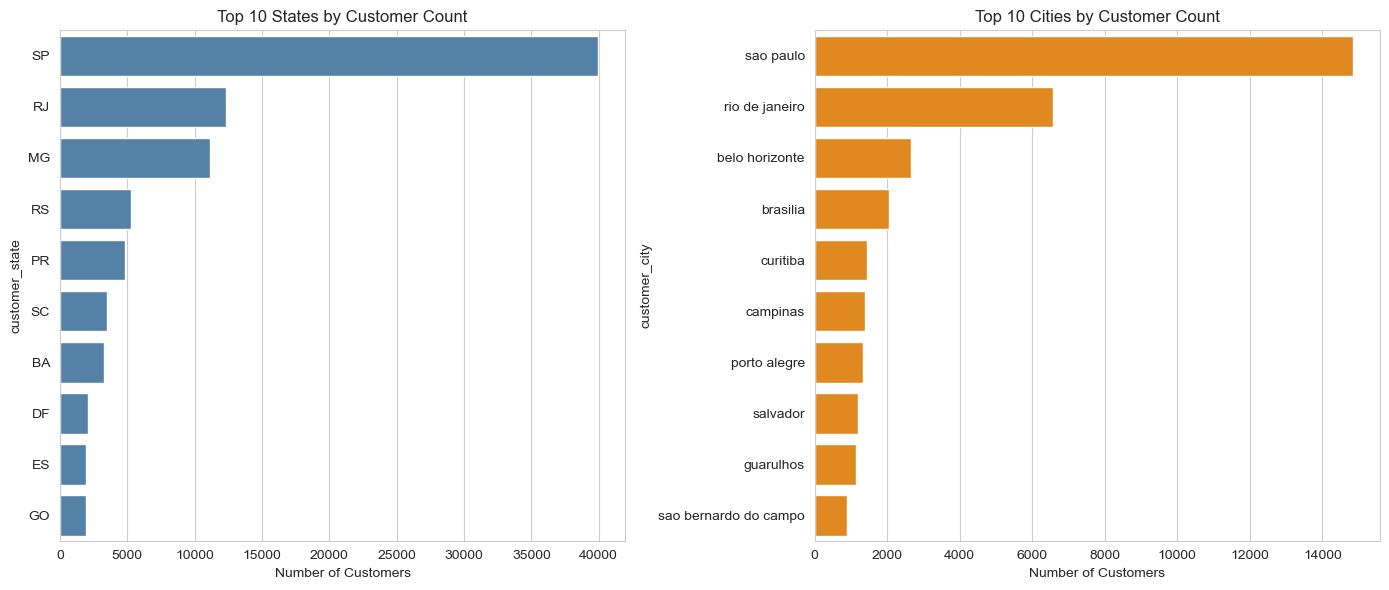

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=state_dist.head(10), x='num_customers', y='customer_state', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 States by Customer Count')
axes[0].set_xlabel('Number of Customers')

sns.barplot(data=city_dist.head(10), x='num_customers', y='customer_city', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Cities by Customer Count')
axes[1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.savefig('../images/customer_geo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Customer geography mirrors the revenue concentration seen in the sales analysis — 
São Paulo state leads with 39,972 customers, and the city of São Paulo alone accounts for 15.6% 
of all customers nationwide. The top 10 cities include both major state capitals and several 
São Paulo metro-area cities, showing the concentration extends beyond just the capital.

## 7. Review Score vs. Repeat Purchase Behavior

**Question:** Do customers who leave higher reviews tend to come back and buy again?

In [14]:
customer_orders = analysis_df.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    avg_review_score=('review_score', 'mean')
).reset_index()

customer_orders['customer_type'] = customer_orders['order_count'].apply(
    lambda x: 'repeat' if x > 1 else 'one-time'
)

review_by_type = customer_orders.groupby('customer_type')['avg_review_score'].agg(['mean', 'count']).reset_index()
review_by_type

,customer_type,mean,count
0,one-time,4.100711,91817
1,repeat,4.137720,2904


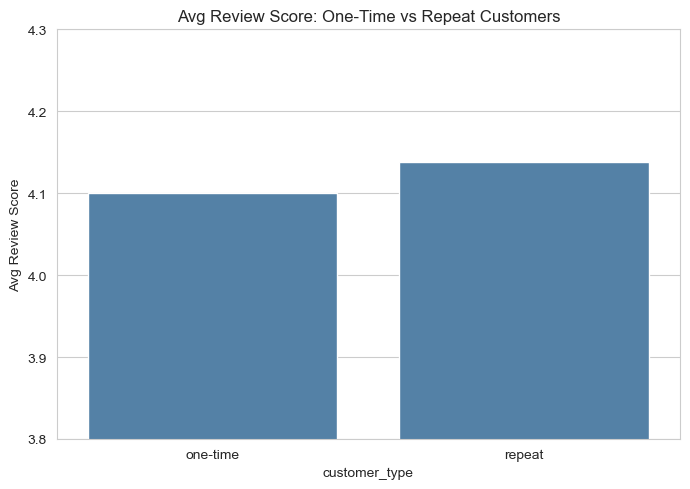

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(data=review_by_type, x='customer_type', y='mean', color='steelblue')
plt.title('Avg Review Score: One-Time vs Repeat Customers')
plt.ylabel('Avg Review Score')
plt.ylim(3.8, 4.3)
plt.tight_layout()
plt.savefig('../images/review_vs_repeat.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Repeat customers have a slightly higher average review score (4.14) than one-time 
customers (4.10) — a small but directionally sensible gap, consistent with satisfied customers 
being more likely to return. The difference is modest, so review score alone is not a strong 
predictor of repeat behavior in this dataset.

## Summary — Key Product & Customer Insights

**Product:**

1. **Revenue is moderately concentrated:** The top 10 of 74 categories generate ~62% of revenue. 
   `health_beauty` leads (R$1.26M), closely followed by `watches_gifts` (R$1.21M) and 
   `bed_bath_table` (R$1.04M).

2. **Volume and premium pricing are largely separate categories:** High-volume categories 
   (bed_bath_table, health_beauty) sit in the R$87-130 average price range, while premium 
   categories (computers at R$1,098 avg) sell in small volumes. `watches_gifts` is the standout 
   exception, combining strong volume (5,991 items) with premium pricing (R$201 avg).

3. **Furniture categories underperform on satisfaction:** Overall average review score is 4.03, 
   but furniture-related categories — especially `office_furniture` (3.49 avg, 1,677 reviews) — 
   rate notably below average, a pattern worth cross-checking against delivery performance next.

**Customer:**

4. **Repeat customers are rare but more valuable:** Only 3.05% of customers made repeat purchases, 
   but they spent nearly 2x more on average (R$262.03 vs R$138.67). Repeat customers still 
   contribute only ~5.6% of total revenue due to their small numbers. Note: the ~2-year dataset 
   window may understate true repeat rates for infrequently-purchased categories.

5. **Customer base is geographically concentrated:** Mirrors the revenue pattern from sales 
   analysis — São Paulo state leads (39,972 customers), with the city of São Paulo alone 
   accounting for 15.6% of all customers nationwide.

6. **Review score has only a mild link to repeat behavior:** Repeat customers rate slightly higher 
   (4.14 vs 4.10) than one-time customers — a real but modest difference, not a strong predictor.

**Next steps:** Delivery performance and its relationship to review scores explored in 
`04_eda_delivery.ipynb` — including whether furniture's lower ratings (insight #3) are linked 
to delivery issues.